In [1]:
import pandas as pd

In [2]:
data_folder = "../data/"
movies_file_path = data_folder + "movies.csv"
ratings_file_path = data_folder + "ratings.csv"

movies = pd.read_csv(movies_file_path,index_col=None)
ratings = pd.read_csv(ratings_file_path,index_col=None)

In [3]:
movies.shape, ratings.shape

((62423, 3), (25000095, 4))

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [7]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


Understanding DATA

In [8]:
movies.isna().sum()

movieId    0
title      0
genres     0
dtype: int64

In [9]:
all_genres = movies['genres'].str.split('|').explode()

genre_counts = all_genres.value_counts()

len(genre_counts)

20

In [10]:
genre_counts

genres
Drama                 25606
Comedy                16870
Thriller               8654
Romance                7719
Action                 7348
Horror                 5989
Documentary            5605
Crime                  5319
(no genres listed)     5062
Adventure              4145
Sci-Fi                 3595
Children               2935
Animation              2929
Mystery                2925
Fantasy                2731
War                    1874
Western                1399
Musical                1054
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

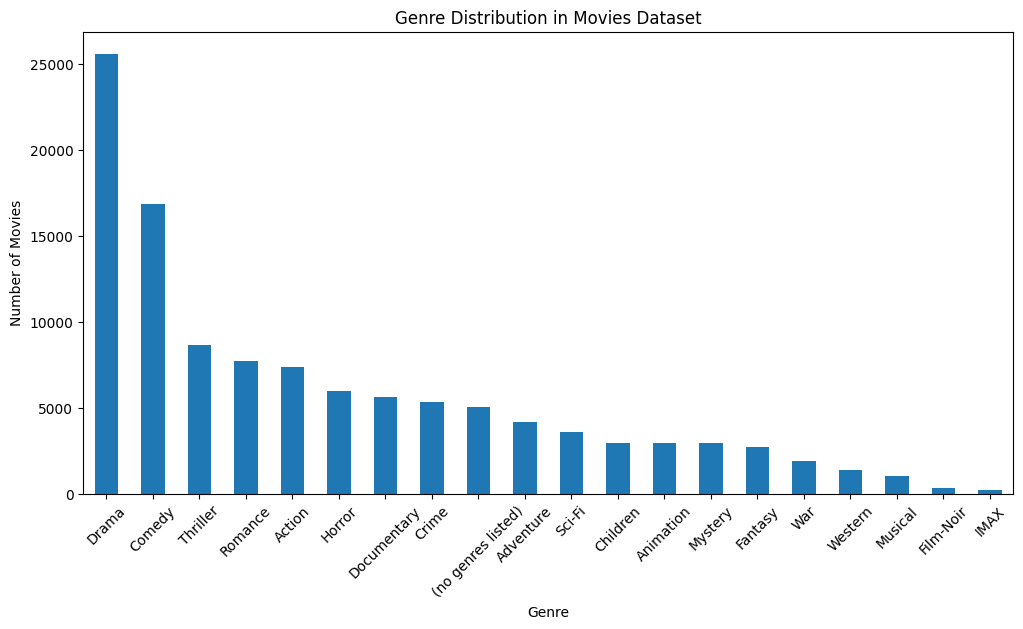

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar')
plt.title("Genre Distribution in Movies Dataset")
plt.ylabel("Number of Movies")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.savefig('genre_count.png')
plt.show()

In [12]:
movies['num_genres'] = movies['genres'].apply(lambda x : len(x.split('|')))

movies['num_genres'].describe()

count    62423.000000
mean         1.799129
std          0.963300
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         10.000000
Name: num_genres, dtype: float64

In [13]:
combination_counts = movies['genres'].value_counts().head(10)
print(combination_counts)

genres
Drama                   9056
Comedy                  5674
(no genres listed)      5062
Documentary             4731
Comedy|Drama            2386
Drama|Romance           2126
Horror                  1661
Comedy|Romance          1577
Comedy|Drama|Romance    1044
Drama|Thriller           933
Name: count, dtype: int64


In [14]:
merged_df = pd.merge(ratings, movies, on='movieId')

merged_df_exploded = merged_df.copy()
merged_df_exploded['genres'] = merged_df_exploded['genres'].str.split('|')
merged_df_exploded = merged_df_exploded.explode('genres')

In [15]:
avg_ratings = merged_df_exploded.groupby('genres')['rating'].mean().sort_values(ascending=False)
print(avg_ratings)

genres
Film-Noir             3.925728
War                   3.791466
Documentary           3.705281
Crime                 3.685044
Drama                 3.677185
Mystery               3.670169
Animation             3.614946
IMAX                  3.603712
Western               3.585755
Musical               3.554716
Romance               3.542712
Thriller              3.522964
Adventure             3.517445
Fantasy               3.511589
Sci-Fi                3.478143
Action                3.466592
Children              3.432507
Comedy                3.423993
(no genres listed)    3.326379
Horror                3.293563
Name: rating, dtype: float64


In [16]:
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['datetime'].dt.year
ratings[['userId', 'movieId', 'rating', 'timestamp', 'year']].head()

,userId,movieId,rating,timestamp,year
0,1,296,5.0,1147880044,2006
1,1,306,3.5,1147868817,2006
2,1,307,5.0,1147868828,2006
3,1,665,5.0,1147878820,2006
4,1,899,3.5,1147868510,2006


In [17]:
movie_year_avg = ratings.groupby(['movieId', 'year'])['rating'].mean().reset_index()
movie_year_avg

,movieId,year,rating
0,1,1996,4.132756
1,1,1997,3.872500
2,1,1998,3.889515
3,1,1999,3.975140
4,1,2000,4.136634
...,...,...,...
323732,209157,2019,1.500000
323733,209159,2019,3.000000
323734,209163,2019,4.500000
323735,209169,2019,3.000000


In [18]:
merged_df = pd.merge(movie_year_avg, movies, on='movieId')
merged_df[['title', 'genres', 'year', 'rating']].head()

,title,genres,year,rating
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1996,4.132756
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1997,3.872500
2,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1998,3.889515
3,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1999,3.975140
4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2000,4.136634


In [19]:
merged_df = merged_df[merged_df['genres'] != '(no genres listed)']
merged_df['genres'] = merged_df['genres'].str.split('|')
merged_df = merged_df.explode('genres')

In [20]:
genre_year_avg = merged_df.groupby(['genres', 'year'])['rating'].mean().reset_index()

genre_year_avg.head()

,genres,year,rating
0,Action,1996,3.354350
1,Action,1997,3.236386
2,Action,1998,3.046791
3,Action,1999,3.017758
4,Action,2000,3.064888


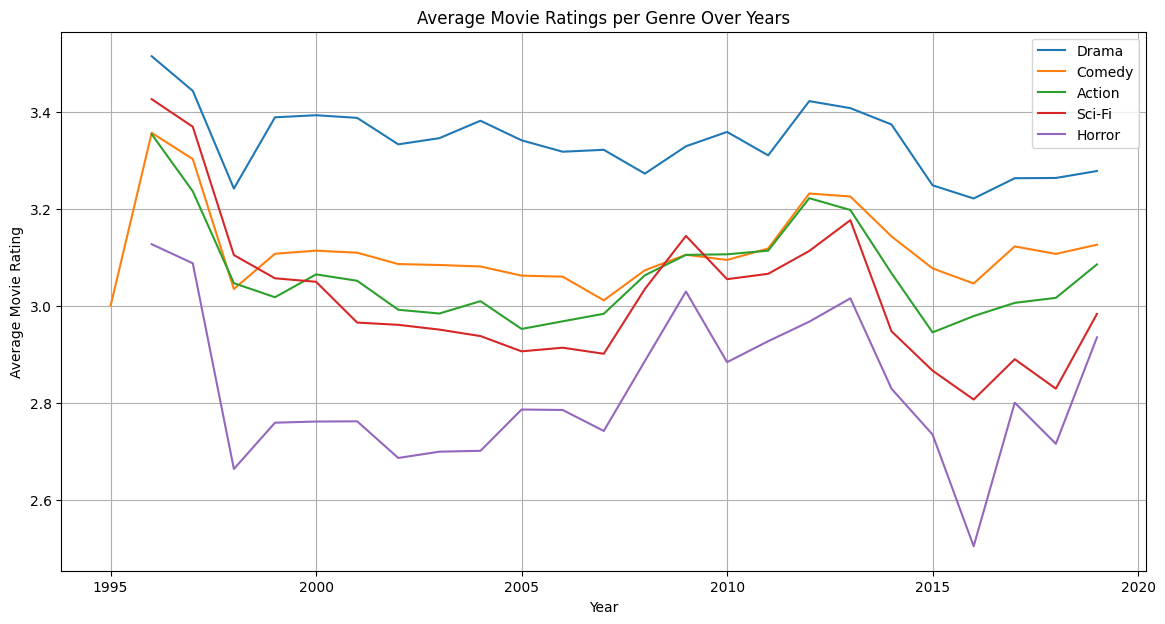

In [21]:
import matplotlib.pyplot as plt

selected_genres = ['Drama', 'Comedy', 'Action', 'Sci-Fi', 'Horror']

plt.figure(figsize=(14, 7))

for genre in selected_genres:
    genre_df = genre_year_avg[genre_year_avg['genres'] == genre]
    plt.plot(genre_df['year'], genre_df['rating'], label=genre)

plt.xlabel("Year")
plt.ylabel("Average Movie Rating")
plt.title("Average Movie Ratings per Genre Over Years")
plt.legend()
plt.grid(True)
plt.savefig('genre_rating.png')
plt.show()

In [22]:
user_rating_counts = ratings.groupby('userId').size()
user_rating_counts

userId
1          70
2         184
3         656
4         242
5         101
         ... 
162537    101
162538    154
162539     47
162540     88
162541    182
Length: 162541, dtype: int64

In [23]:
movie_rating_counts = ratings.groupby('movieId').size()
movie_rating_counts

movieId
1         57309
2         24228
3         11804
4          2523
5         11714
          ...  
209157        1
209159        1
209163        1
209169        1
209171        1
Length: 59047, dtype: int64

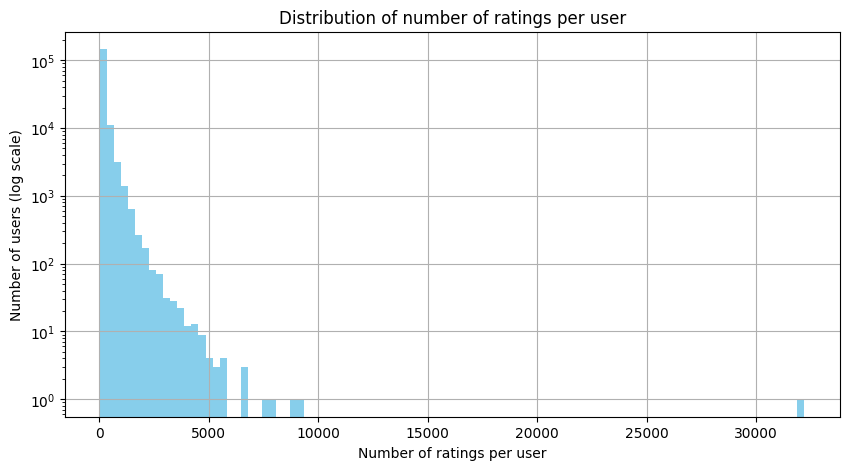

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(user_rating_counts, bins=100, log=True, color='skyblue')
plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users (log scale)")
plt.title("Distribution of number of ratings per user")
plt.grid(True)
plt.savefig('user_ratings_count.png')
plt.show()

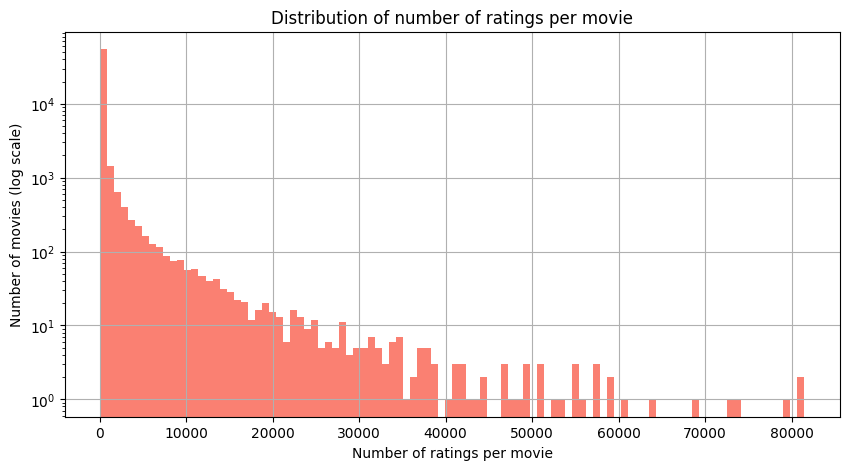

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(movie_rating_counts, bins=100, log=True, color='salmon')
plt.xlabel("Number of ratings per movie")
plt.ylabel("Number of movies (log scale)")
plt.title("Distribution of number of ratings per movie")
plt.grid(True)
plt.savefig('ratings_per_movie.png')
plt.show()

In [26]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

sparsity = 1 - (num_ratings / (num_users * num_movies))
print(f"Sparsity of user-item matrix: {sparsity:.4f}")

Sparsity of user-item matrix: 0.9974
